[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Laverde97/phd-data-science-ai/blob/main/semesters/semester-01/machine-learning/notebooks/learning-guides/05-redes-neuronales-artificiales.ipynb)

# 🧠 Guía práctica: Redes Neuronales Artificiales (RNA)

**Doctorado en Ciencia de Datos e Inteligencia Artificial**  
**Autor:** Juan Sebastián Laverde Chunza

---

## Propósito de esta guía

Esta guía explica las **Redes Neuronales Artificiales (RNA)** de una manera sencilla, visual y práctica.

Al finalizar podrás:

- comprender qué significa que una red neuronal **aprenda**;
- reconocer sus principales elementos: **entradas, pesos, sesgo, neuronas, funciones de activación y salida**;
- entender intuitivamente el proceso de **backpropagation**;
- construir y probar una red neuronal sencilla en Python;
- preparar un archivo para trabajar posteriormente con **Tiberius Data Mining Suite**.

> **Idea principal:** una red neuronal no “adivina”. Aprende patrones ajustando números internos llamados **pesos** para reducir sus errores.



## 1. ¿Qué es una Red Neuronal Artificial?

Una **Red Neuronal Artificial (RNA)** es un modelo computacional formado por unidades llamadas **neuronas artificiales** conectadas entre sí.

Cada neurona recibe información, realiza una operación matemática y produce una salida.

### Ejemplo de la vida real

Imagina una aplicación que intenta decidir si mañana debes **llevar paraguas**.

Puede utilizar como entradas:

- humedad;
- porcentaje de nubosidad;
- probabilidad de lluvia del pronóstico;
- presión atmosférica.

La red combina estas variables y produce una salida como:

> **Probabilidad de lluvia = 87 %**

La red aprendió porque durante el entrenamiento comparó muchas predicciones con resultados reales y fue ajustando sus parámetros internos.

### Relación con el cerebro

Las RNA fueron inspiradas parcialmente en la idea de neuronas interconectadas del cerebro, pero **no son una copia del cerebro humano**. Son modelos matemáticos que procesan datos mediante operaciones numéricas.



## 2. La neurona artificial

Una neurona artificial puede resumirse así:

\[
z = b + w_1x_1 + w_2x_2 + \cdots + w_nx_n
\]

y después:

\[
\hat{y} = f(z)
\]

donde:

- \(x_i\): datos de **entrada**;
- \(w_i\): **pesos** asignados a cada entrada;
- \(b\): **sesgo** o *bias*;
- \(f\): **función de activación**;
- \(\hat{y}\): salida o predicción.

En la guía original, el sesgo puede representarse como \(W_0X_0\), usando normalmente \(X_0=1\). Ambas formas expresan la misma idea.


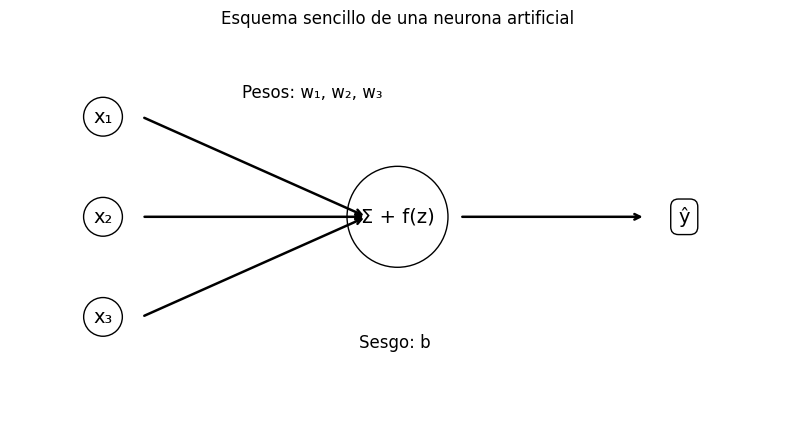

In [1]:

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis("off")

inputs = [(0.12, 0.78, "x₁"), (0.12, 0.52, "x₂"), (0.12, 0.26, "x₃")]
for x, y, label in inputs:
    ax.text(x, y, label, fontsize=14, ha="center", va="center",
            bbox=dict(boxstyle="circle,pad=0.5", fill=False))
    ax.annotate("", xy=(0.46, 0.52), xytext=(x+0.05, y),
                arrowprops=dict(arrowstyle="->", lw=1.8))

ax.text(0.50, 0.52, "Σ + f(z)", fontsize=14, ha="center", va="center",
        bbox=dict(boxstyle="circle,pad=0.7", fill=False))
ax.annotate("", xy=(0.82, 0.52), xytext=(0.58, 0.52),
            arrowprops=dict(arrowstyle="->", lw=1.8))
ax.text(0.87, 0.52, "ŷ", fontsize=14, ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.4", fill=False))

ax.text(0.30, 0.83, "Pesos: w₁, w₂, w₃", fontsize=12)
ax.text(0.45, 0.18, "Sesgo: b", fontsize=12)

plt.title("Esquema sencillo de una neurona artificial")
plt.show()



## 3. Conceptos fundamentales, explicados de forma fácil

| Concepto | Definición sencilla | Ejemplo cotidiano |
|---|---|---|
| **Entrada** | Información que recibe la red. | Humedad, temperatura o edad de un vehículo. |
| **Peso** | Número que indica cuánto influye una entrada. | Si la humedad es muy importante para predecir lluvia, su peso puede aumentar. |
| **Sesgo (bias)** | Ajuste adicional que permite desplazar la decisión de la neurona. | Como mover ligeramente el punto a partir del cual se activa una alarma. |
| **Neurona artificial** | Unidad que combina entradas y produce una salida. | Una pequeña “calculadora” dentro de la red. |
| **Función de activación** | Decide cómo transformar la información calculada por la neurona. | Puede convertir un valor en una probabilidad entre 0 y 1. |
| **Salida** | Predicción generada por la red. | “Spam”, “no spam”, o un precio estimado. |
| **Error** | Diferencia entre lo predicho y lo esperado. | Predijo 80 y el valor real era 100. |
| **Época** | Una pasada completa por todos los datos de entrenamiento. | Repasar una vez todo un libro de ejercicios. |
| **Aprender** | Ajustar los pesos para reducir el error. | Corregir una técnica después de revisar los errores. |
| **Tasa de aprendizaje** | Tamaño del ajuste aplicado a los pesos. | Corregir poco a poco o hacer cambios demasiado grandes. |
| **Vector** | Conjunto ordenado de números. | `[humedad, temperatura, nubosidad]`. |
| **Red neuronal** | Conjunto de neuronas conectadas. | Varias unidades trabajando juntas para obtener una predicción. |

> **Aclaración:** en esta guía usamos la convención moderna en la que la **salida** es la predicción de la red. Los **pesos** son parámetros internos que la red aprende.



## 4. ¿Qué significa que una red neuronal “aprenda”?

Una red **aprende** cuando encuentra valores de los pesos que producen predicciones cada vez más cercanas a los resultados reales.

### Analogía sencilla

Piensa en una persona aprendiendo a lanzar una pelota a una canasta:

1. realiza un lanzamiento;
2. observa qué tan lejos cayó;
3. corrige fuerza y dirección;
4. vuelve a intentarlo;
5. repite hasta mejorar.

Una red neuronal hace algo parecido:

1. genera una predicción;
2. calcula el error;
3. utiliza el error para ajustar sus pesos;
4. vuelve a predecir;
5. repite durante varias épocas.



## 5. Funciones de activación

La guía base presenta funciones como:

- lineal;
- escalón;
- lineal a tramos;
- sigmoidea;
- gaussiana;
- sinusoidal.

En aprendizaje profundo moderno también es muy común utilizar **ReLU**.

### ¿Para qué sirven?

La función de activación transforma el resultado interno de una neurona. Dependiendo del problema, puede ayudar a:

- producir una decisión 0/1;
- generar una probabilidad;
- conservar un valor continuo;
- introducir relaciones no lineales.


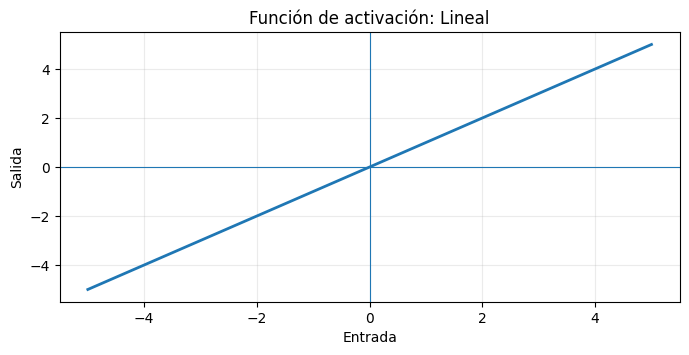

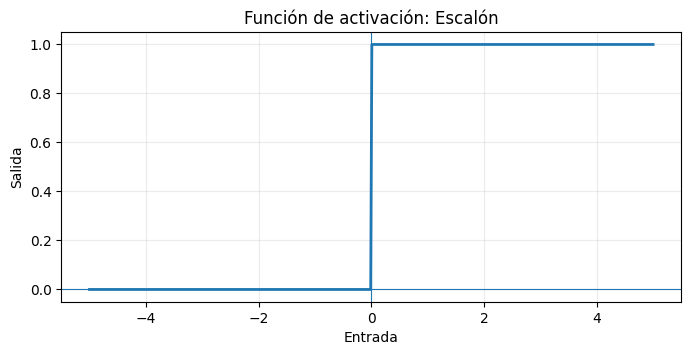

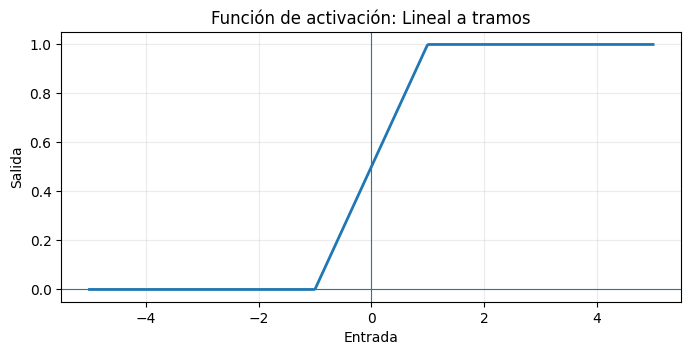

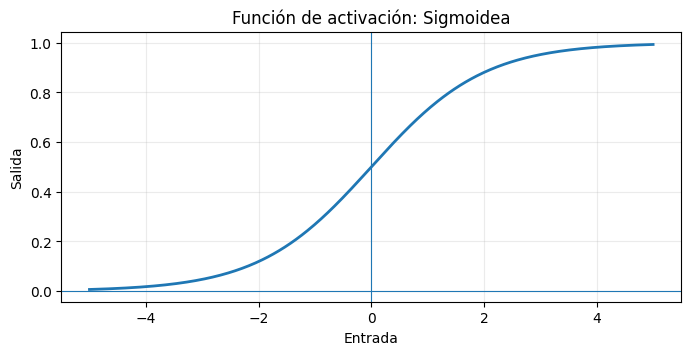

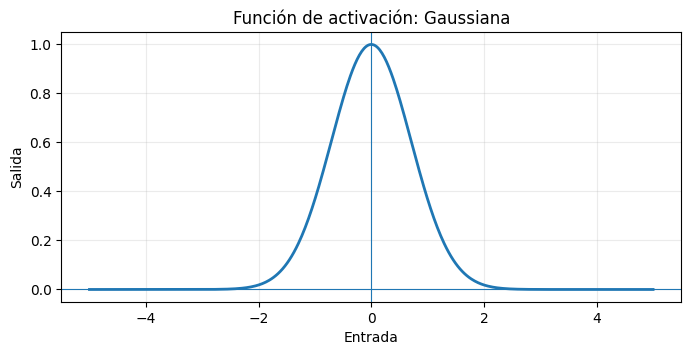

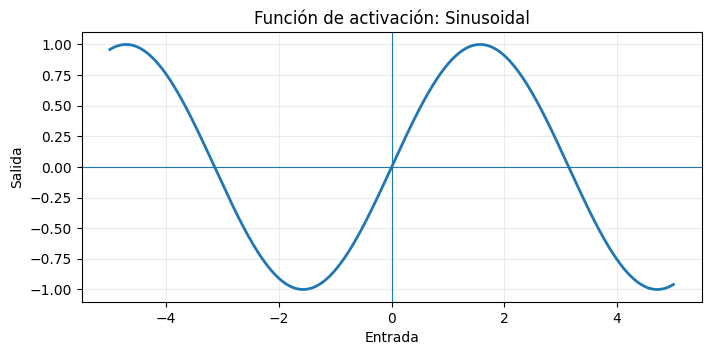

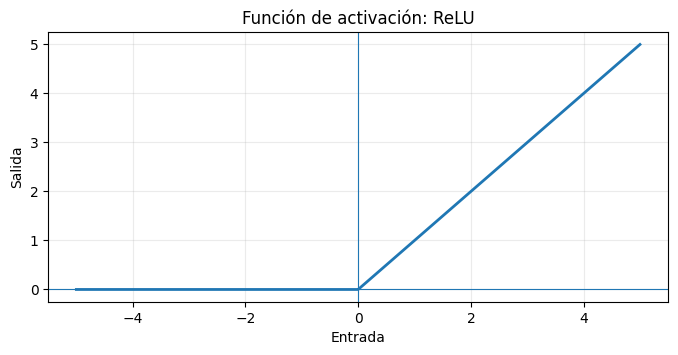

In [2]:

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 500)

funciones = {
    "Lineal": x,
    "Escalón": np.where(x >= 0, 1, 0),
    "Lineal a tramos": np.clip((x + 1) / 2, 0, 1),
    "Sigmoidea": 1 / (1 + np.exp(-x)),
    "Gaussiana": np.exp(-(x**2)),
    "Sinusoidal": np.sin(x),
    "ReLU": np.maximum(0, x),
}

for nombre, y in funciones.items():
    plt.figure(figsize=(8, 3.5))
    plt.plot(x, y, linewidth=2)
    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)
    plt.title(f"Función de activación: {nombre}")
    plt.xlabel("Entrada")
    plt.ylabel("Salida")
    plt.grid(alpha=0.25)
    plt.show()



## 6. Ejemplo manual de una neurona: ¿llevar paraguas?

Supongamos que usamos tres entradas normalizadas:

- \(x_1\): humedad;
- \(x_2\): nubosidad;
- \(x_3\): probabilidad del pronóstico.

La neurona tiene pesos y sesgo ya aprendidos. Aplicaremos una función sigmoidea para producir una probabilidad.


In [3]:

import numpy as np

# Entradas
x = np.array([0.90, 0.80, 0.75])

# Pesos aprendidos (ejemplo didáctico)
w = np.array([1.10, 0.70, 1.40])

# Sesgo
b = -1.20

# Combinación lineal
z = np.dot(x, w) + b

# Función sigmoidea
probabilidad = 1 / (1 + np.exp(-z))

print("=" * 60)
print("PREDICCIÓN SENCILLA DE UNA NEURONA")
print("=" * 60)
print(f"Valor interno z: {z:.4f}")
print(f"Probabilidad estimada de lluvia: {probabilidad:.2%}")

if probabilidad >= 0.5:
    print("Decisión didáctica: llevar paraguas ☔")
else:
    print("Decisión didáctica: probablemente no sea necesario llevar paraguas.")


PREDICCIÓN SENCILLA DE UNA NEURONA
Valor interno z: 1.4000
Probabilidad estimada de lluvia: 80.22%
Decisión didáctica: llevar paraguas ☔



## 7. Ejemplo de la guía: perceptrón para la implicación lógica

La guía original utiliza la operación lógica:

\[
X_1 \rightarrow X_2
\]

La implicación solamente es **falsa (0)** cuando:

\[
X_1=1 \quad \text{y} \quad X_2=0
\]

Para los demás casos, la salida es **1**.

La función de activación utilizada es una **función escalón**:

\[
F(x)=
\begin{cases}
1 & \text{si } x \geq 0\\
0 & \text{si } x < 0
\end{cases}
\]

La guía proporciona los pesos:

\[
W_0=0.5,\qquad W_1=-1.5,\qquad W_2=2.5
\]

con \(X_0=1\).


In [4]:

import pandas as pd

def escalon(valor):
    return 1 if valor >= 0 else 0

W0 = 0.5
W1 = -1.5
W2 = 2.5
X0 = 1

datos = [
    (0, 0, 1),
    (0, 1, 1),
    (1, 0, 0),
    (1, 1, 1),
]

resultados = []

for X1, X2, salida_deseada in datos:
    z = W0*X0 + W1*X1 + W2*X2
    salida_predicha = escalon(z)

    resultados.append({
        "X1": X1,
        "X2": X2,
        "Salida deseada": salida_deseada,
        "z": z,
        "Salida predicha": salida_predicha,
        "¿Correcto?": salida_predicha == salida_deseada
    })

tabla = pd.DataFrame(resultados)
display(tabla)

exactitud = tabla["¿Correcto?"].mean()

print(f"\nExactitud del perceptrón: {exactitud:.0%}")


,X1,X2,Salida deseada,z,Salida predicha,¿Correcto?
0,0,0,1,0.5,1,True
1,0,1,1,3.0,1,True
2,1,0,0,-1.0,0,True
3,1,1,1,1.5,1,True



Exactitud del perceptrón: 100%



### Interpretación

El perceptrón reproduce correctamente las cuatro combinaciones posibles.

Eso significa que, para este pequeño problema, los pesos encontrados permiten obtener la salida deseada en todos los casos.

Esta es una forma sencilla de entender la frase:

> **La red ha aprendido los pesos necesarios para resolver el patrón.**



## 8. ¿Qué es Backpropagation?

**Backpropagation** o **propagación hacia atrás** es el procedimiento que permite utilizar el error de la red para ajustar los pesos.

### Explicación fácil

Supongamos que una red predice que una vivienda cuesta **350 millones**, pero el valor real era **400 millones**.

Existe un error de **50 millones**.

Durante el entrenamiento:

1. **Propagación hacia adelante:** los datos pasan desde la entrada hasta la salida.
2. **Cálculo del error:** se compara la predicción con el valor real.
3. **Propagación hacia atrás:** se determina cómo contribuyó cada peso al error.
4. **Actualización:** los pesos se modifican ligeramente.
5. **Nueva época:** el procedimiento vuelve a comenzar.

La meta no es memorizar cada ejemplo, sino aprender patrones que también funcionen con datos que la red no vio durante el entrenamiento.


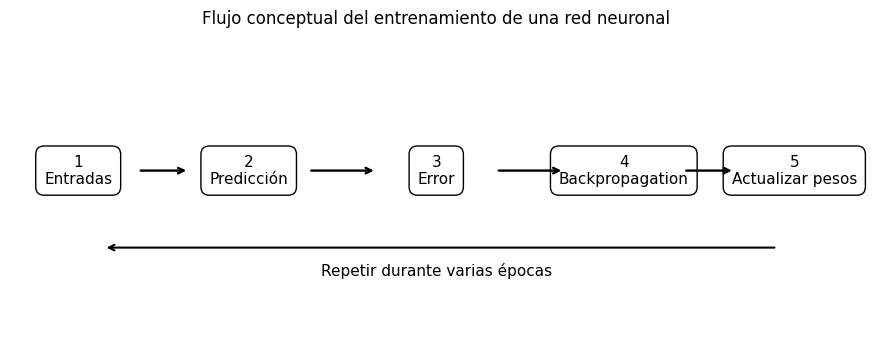

In [5]:

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 4))
ax.axis("off")

pasos = [
    (0.08, "1\nEntradas"),
    (0.28, "2\nPredicción"),
    (0.50, "3\nError"),
    (0.72, "4\nBackpropagation"),
    (0.92, "5\nActualizar pesos"),
]

for x_pos, texto in pasos:
    ax.text(
        x_pos, 0.55, texto,
        ha="center", va="center", fontsize=11,
        bbox=dict(boxstyle="round,pad=0.55", fill=False)
    )

for i in range(len(pasos) - 1):
    ax.annotate(
        "",
        xy=(pasos[i+1][0] - 0.07, 0.55),
        xytext=(pasos[i][0] + 0.07, 0.55),
        arrowprops=dict(arrowstyle="->", lw=1.7)
    )

ax.annotate(
    "",
    xy=(0.11, 0.30),
    xytext=(0.90, 0.30),
    arrowprops=dict(arrowstyle="->", lw=1.5)
)
ax.text(0.50, 0.21, "Repetir durante varias épocas", ha="center", fontsize=11)

plt.title("Flujo conceptual del entrenamiento de una red neuronal")
plt.show()



## 9. Arquitectura de una red neuronal

Una red suele organizarse en **capas**:

### Capa de entrada
Recibe las variables del problema.

### Capa(s) oculta(s)
Realizan transformaciones intermedias y aprenden combinaciones de las variables.

### Capa de salida
Produce la predicción final.

### Ejemplo real

Para clasificar un vino a partir de mediciones químicas:

- **Entradas:** alcohol, magnesio, intensidad de color, etc.
- **Capas ocultas:** combinan estas características.
- **Salida:** clase de vino predicha.


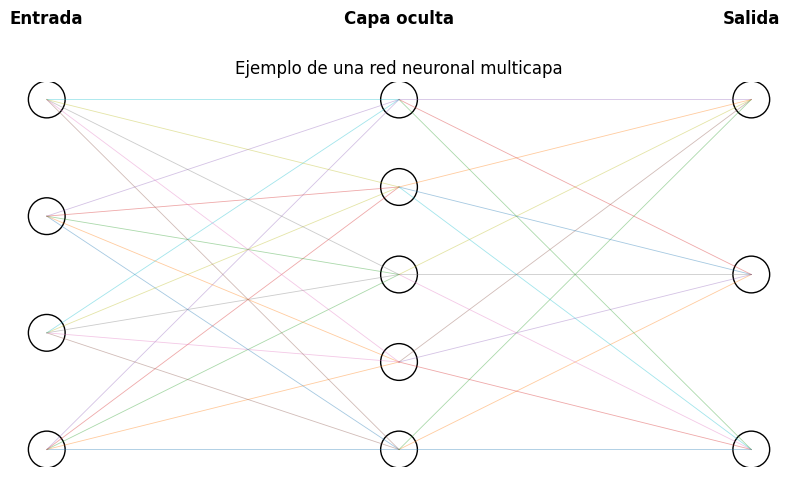

In [6]:

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis("off")

layer_x = [0.15, 0.50, 0.85]
layer_counts = [4, 5, 3]
layer_names = ["Entrada", "Capa oculta", "Salida"]

coordinates = []

for x_pos, count, name in zip(layer_x, layer_counts, layer_names):
    ys = np.linspace(0.2, 0.8, count)
    current = []
    for y_pos in ys:
        ax.scatter(x_pos, y_pos, s=700, facecolors="none", edgecolors="black")
        current.append((x_pos, y_pos))
    coordinates.append(current)
    ax.text(x_pos, 0.93, name, ha="center", fontsize=12, fontweight="bold")

for a, b in zip(coordinates[:-1], coordinates[1:]):
    for x1, y1 in a:
        for x2, y2 in b:
            ax.plot([x1, x2], [y1, y2], linewidth=0.6, alpha=0.4)

plt.title("Ejemplo de una red neuronal multicapa")
plt.show()



# 10. Práctica en Colab: construir una red neuronal

Utilizaremos el conjunto de datos **Wine** incluido en `scikit-learn`.

Es un conjunto de datos real utilizado con fines educativos. Contiene mediciones químicas de vinos y una variable objetivo con tres clases.

La práctica seguirá este flujo:

1. cargar los datos;
2. explorar sus dimensiones;
3. separar entrenamiento y prueba;
4. estandarizar las variables;
5. entrenar una red neuronal multicapa;
6. evaluar su rendimiento;
7. observar cómo disminuye la función de pérdida.


In [7]:

from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine(as_frame=True)

X = wine.data
y = wine.target

dataset = X.copy()
dataset["clase"] = y

print("=" * 70)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 70)
print(f"Número de observaciones: {dataset.shape[0]}")
print(f"Número de variables predictoras: {X.shape[1]}")
print(f"Número de clases: {y.nunique()}")

display(dataset.head())


INFORMACIÓN GENERAL DEL DATASET
Número de observaciones: 178
Número de variables predictoras: 13
Número de clases: 3


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,clase
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



## 10.1 Separación de los datos

Usaremos:

- **80 %** para entrenamiento;
- **20 %** para prueba.

El conjunto de prueba simula datos nuevos que la red no utilizó para aprender.


In [8]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} registros")
print(f"Prueba:        {X_test.shape[0]} registros")


Entrenamiento: 142 registros
Prueba:        36 registros



## 10.2 Estandarización

Las redes neuronales suelen entrenarse mejor cuando las variables se encuentran en escalas comparables.

Por ejemplo:

- una variable podría tomar valores entre 0 y 1;
- otra entre 100 y 1.000.

La estandarización transforma las variables para que tengan una escala más homogénea.


In [9]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos estandarizados correctamente.")


Datos estandarizados correctamente.



## 10.3 Entrenamiento de la red

Crearemos una red con:

- **13 entradas**, una por cada variable del dataset;
- **1 capa oculta de 10 neuronas**;
- función de activación **ReLU**;
- algoritmo de optimización **Adam**;
- máximo de **2.000 iteraciones**.

`MLPClassifier` entrena una red neuronal multicapa utilizando backpropagation.


In [10]:

from sklearn.neural_network import MLPClassifier

modelo = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation="relu",
    solver="adam",
    max_iter=2000,
    random_state=42
)

modelo.fit(X_train_scaled, y_train)

print("=" * 70)
print("ENTRENAMIENTO COMPLETADO")
print("=" * 70)
print(f"Iteraciones realizadas: {modelo.n_iter_}")
print(f"Capas internas reportadas por el modelo: {modelo.n_layers_}")
print(f"Número de salidas: {modelo.n_outputs_}")


ENTRENAMIENTO COMPLETADO
Iteraciones realizadas: 604
Capas internas reportadas por el modelo: 3
Número de salidas: 3



## 10.4 Evaluación

La **exactitud (accuracy)** representa la proporción de casos correctamente clasificados.

También observaremos la **matriz de confusión**, que permite comparar las clases reales frente a las predichas.


In [11]:

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = modelo.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
matriz = confusion_matrix(y_test, y_pred)

print("=" * 70)
print("RESULTADOS DEL MODELO")
print("=" * 70)
print(f"Exactitud en prueba: {accuracy:.2%}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=wine.target_names))


RESULTADOS DEL MODELO
Exactitud en prueba: 100.00%

Reporte de clasificación:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



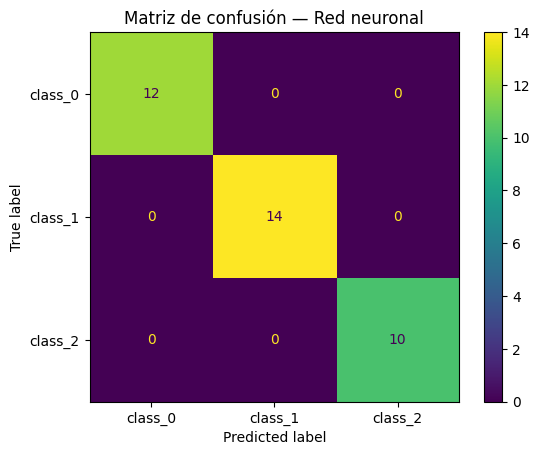

In [12]:

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=wine.target_names
)

disp.plot()
plt.title("Matriz de confusión — Red neuronal")
plt.show()



## 10.5 ¿La red fue aprendiendo?

Durante el entrenamiento, `MLPClassifier` registra el valor de la función de pérdida.

Si el entrenamiento funciona adecuadamente, esperamos observar una tendencia general descendente.


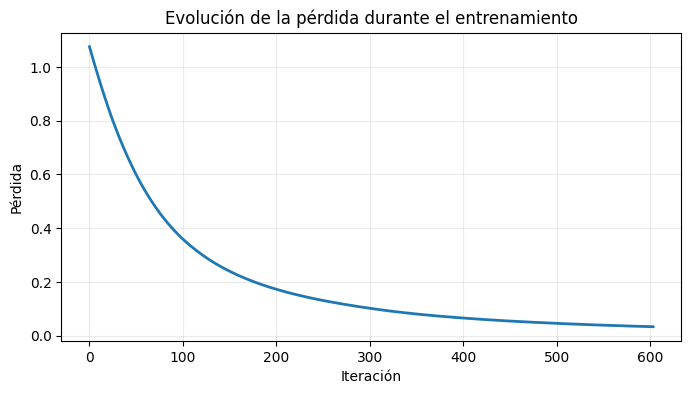

Pérdida inicial aproximada: 1.0753
Pérdida final aproximada:   0.0335


In [13]:

plt.figure(figsize=(8, 4))
plt.plot(modelo.loss_curve_, linewidth=2)
plt.title("Evolución de la pérdida durante el entrenamiento")
plt.xlabel("Iteración")
plt.ylabel("Pérdida")
plt.grid(alpha=0.25)
plt.show()

print(f"Pérdida inicial aproximada: {modelo.loss_curve_[0]:.4f}")
print(f"Pérdida final aproximada:   {modelo.loss_curve_[-1]:.4f}")



## 10.6 Predicción de un caso

Tomaremos una observación del conjunto de prueba y pediremos a la red que determine su clase.


In [14]:

indice = 0

caso = X_test.iloc[[indice]]
caso_scaled = scaler.transform(caso)

prediccion = modelo.predict(caso_scaled)[0]
probabilidades = modelo.predict_proba(caso_scaled)[0]

print("=" * 70)
print("PREDICCIÓN DE UNA OBSERVACIÓN")
print("=" * 70)
print(f"Clase real:      {wine.target_names[y_test.iloc[indice]]}")
print(f"Clase predicha:  {wine.target_names[prediccion]}")
print("\nProbabilidades:")

for nombre, prob in zip(wine.target_names, probabilidades):
    print(f"  {nombre}: {prob:.2%}")


PREDICCIÓN DE UNA OBSERVACIÓN
Clase real:      class_0
Clase predicha:  class_0

Probabilidades:
  class_0: 99.99%
  class_1: 0.01%
  class_2: 0.00%



## 11. Ejemplos reales donde se utilizan redes neuronales

Las redes neuronales aparecen en muchos contextos:

| Área | Ejemplo |
|---|---|
| **Visión por computador** | Reconocer objetos, defectos industriales o patrones en imágenes. |
| **Procesamiento de lenguaje** | Traducir textos, resumir documentos o responder preguntas. |
| **Finanzas** | Detectar operaciones anómalas o estimar patrones de riesgo. |
| **Industria** | Predecir fallas de maquinaria mediante sensores. |
| **Comercio** | Recomendar productos según comportamiento de usuarios. |
| **Transporte** | Estimar demanda, tiempos de viaje o congestión. |
| **Salud** | Apoyar investigación en imágenes y datos biomédicos. |
| **Agricultura** | Detectar enfermedades en cultivos a partir de imágenes. |

> En aplicaciones de alto impacto, como salud o finanzas, una red neuronal debe evaluarse cuidadosamente antes de utilizarse para apoyar decisiones reales.



# 12. Tiberius Data Mining Suite para Redes Neuronales

## ¿Qué es?

**Tiberius Data Mining Suite** es una herramienta de escritorio orientada a modelamiento predictivo y minería de datos. Entre sus funcionalidades históricas se encuentran las **redes neuronales**.

Esta sección se refiere a **Tiberius Data Mining Suite**, el software clásico de análisis predictivo para Windows.

> **No confundir** con otro proyecto moderno llamado *Tiberius* orientado a predicción de genes mediante deep learning.

### Idea del flujo de trabajo

La documentación disponible de Tiberius para redes neuronales propone, en esencia:

1. preparar los datos de entrenamiento en formato numérico;
2. normalizar o escalar las variables;
3. crear una nueva red neuronal;
4. cargar un archivo CSV;
5. seleccionar las variables de **entrada**;
6. seleccionar la variable **objetivo**;
7. definir la topología de la red;
8. definir parámetros como tasa de aprendizaje e iteraciones;
9. iniciar el entrenamiento;
10. comparar las salidas calculadas con las salidas reales;
11. revisar resultados y, en algunas versiones, generar código del modelo.

### Importante para esta guía

Tiberius es una aplicación de escritorio y **no se ejecuta dentro de Google Colab** como una librería de Python.

La estrategia será:

> **Colab → preparar datos → exportar CSV → abrir el CSV en Tiberius → entrenar y validar la RNA**



## 12.1 Preparar desde Colab un CSV compatible con Tiberius

Como Tiberius trabaja con variables numéricas, exportaremos el dataset Wine con:

- las 13 variables predictoras;
- una columna final llamada `clase`;
- valores numéricos;
- sin índice de pandas.


In [15]:

datos_tiberius = X.copy()
datos_tiberius["clase"] = y

archivo_tiberius = "datos_tiberius_red_neuronal.csv"
datos_tiberius.to_csv(archivo_tiberius, index=False)

print("=" * 70)
print("ARCHIVO PREPARADO PARA TIBERIUS")
print("=" * 70)
print(f"Nombre: {archivo_tiberius}")
print(f"Filas:  {datos_tiberius.shape[0]}")
print(f"Columnas: {datos_tiberius.shape[1]}")
print("\nPrimeros registros:")
display(datos_tiberius.head())


ARCHIVO PREPARADO PARA TIBERIUS
Nombre: datos_tiberius_red_neuronal.csv
Filas:  178
Columnas: 14

Primeros registros:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,clase
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [16]:

# Esta celda descargará el CSV automáticamente si el notebook se ejecuta en Google Colab.

try:
    from google.colab import files
    files.download("datos_tiberius_red_neuronal.csv")
except ImportError:
    print("Esta sesión no es Google Colab.")
    print("El archivo 'datos_tiberius_red_neuronal.csv' quedó guardado en el directorio actual.")


Esta sesión no es Google Colab.
El archivo 'datos_tiberius_red_neuronal.csv' quedó guardado en el directorio actual.



## 12.2 Pasos sugeridos dentro de Tiberius

Una vez descargado `datos_tiberius_red_neuronal.csv`:

### Paso 1 — Crear una nueva red neuronal
Abre Tiberius y crea un nuevo modelo de **Neural Network**.

### Paso 2 — Cargar el CSV
Selecciona el archivo:

`datos_tiberius_red_neuronal.csv`

### Paso 3 — Definir entradas y salida
Usa como **entradas** las variables químicas del vino.

Usa como **salida/target**:

`clase`

### Paso 4 — Revisar escalamiento
Las redes neuronales son sensibles a diferencias grandes de escala. Si la versión de Tiberius utilizada permite normalización, aplícala antes de entrenar.

### Paso 5 — Elegir la red
Para comenzar, utiliza una arquitectura sencilla con una capa oculta.

### Paso 6 — Configurar entrenamiento
Revisa especialmente:

- número de iteraciones;
- tasa de aprendizaje;
- criterio de convergencia.

### Paso 7 — Entrenar
Inicia el entrenamiento y observa la evolución del error.

### Paso 8 — Validar
Compara:

- valor real;
- valor predicho;
- error del modelo.

La validación es fundamental para determinar si la red aprendió un patrón útil y no solamente memorizó los datos de entrenamiento.



## 12.3 Equivalencia conceptual: Colab vs. Tiberius

| Concepto | En Python / Colab | En Tiberius |
|---|---|---|
| Cargar datos | `pandas.read_csv()` | Cargar archivo CSV |
| Variables de entrada | `X` | Inputs |
| Variable objetivo | `y` | Target / Output |
| Escalar datos | `StandardScaler()` | Normalización/escalamiento disponible en el flujo |
| Arquitectura | `hidden_layer_sizes=(10,)` | Configuración de la red |
| Entrenamiento | `modelo.fit()` | Start Training |
| Iteraciones | `max_iter` | Training Iterations |
| Tasa de aprendizaje | `learning_rate_init` | Learning Rate |
| Evaluación | métricas y matriz de confusión | Results / Validation |



# 13. Conclusiones

1. Una red neuronal recibe **entradas**, las multiplica por **pesos** y genera una **salida**.
2. **Aprender** significa ajustar los pesos para disminuir el error.
3. Las **funciones de activación** permiten transformar la información y modelar relaciones complejas.
4. Una **época** corresponde a una pasada completa por los datos de entrenamiento.
5. **Backpropagation** utiliza el error para ajustar los pesos desde la salida hacia las capas anteriores.
6. Una red debe evaluarse con datos que no utilizó para entrenarse.
7. Colab permite comprender y programar las RNA; Tiberius ofrece un enfoque gráfico clásico para crear, entrenar y validar modelos predictivos.

---

## Referencias y material base

- Documento suministrado: **Concepto RNA.docx**.
- Tutorial de redes neuronales con Tiberius Data Mining Suite, University of Rhode Island:  
  https://homepage.cs.uri.edu/faculty/hamel/courses/2015/spring2015/csc481/tiberius-howto.pdf
- `scikit-learn`: conjunto de datos Wine y `MLPClassifier`.

> **Nota sobre Tiberius:** las referencias históricas consultadas describen Tiberius Data Mining como software de escritorio para Windows. El sitio original `tiberius.biz` no respondió durante la verificación de esta guía, por lo que debe considerarse una herramienta *legacy*. Si se necesita instalarlo, conviene verificar cuidadosamente la fuente del instalador antes de ejecutarlo.
